In [18]:
import numpy as np
from tueplots import bundles
import scipy.stats as stats
import matplotlib.pyplot as plt

## setting matplotlib context
from cycler import cycler
from matplotlib.cm import get_cmap
cmap = get_cmap("tab10",8)
palette = [cmap(i) for i in range(8)]
rc = bundles.neurips2024(usetex=False)
rc.update({
    # Set the line/bar color cycle (this is what affects ax.plot)
    "axes.prop_cycle": cycler(color=palette),
    # Optional readability tweaks
    "legend.frameon": False,
    "axes.grid": False,
})

/var/folders/cx/cy7pq56x7m32_zfmgnslz8cnlnlryt/T/ipykernel_72584/4093800120.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap("tab10",8)


In [19]:
np.random.seed(0)

N = 10000
n_train = 5000
sigma = 1.0
alpha = 0.01
eps = 1e-12
Rs = np.arange(1,6)*1000

x_targets = stats.norm.rvs(loc=0.0, scale=sigma, size=N)

eta = x_targets**2 / (2. * (n_train - 1) * sigma**2)
eta = np.maximum(eta, eps)

sd = np.sqrt(2.0 * eta)[:, None]  

all_llrs_in  = stats.norm.rvs(loc=+eta[:, None], scale=sd, size=(N, Rs[-1]))
all_llrs_out = stats.norm.rvs(loc=-eta[:, None], scale=sd, size=(N, Rs[-1]))
all_llrs_in_pp  = (all_llrs_in  + eta[:, None]) / sd
all_llrs_out_pp = (all_llrs_out + eta[:, None]) / sd

In [20]:
TPRs_pooled, TPRs_pooled_pp, TPRs_px = [],[], []
for R in Rs:
    llrs_in_pp, llrs_out_pp = all_llrs_in_pp[:,:R], all_llrs_out_pp[:,:R]
    llrs_in, llrs_out = all_llrs_in[:,:R], all_llrs_out[:,:R]

    tau_i_hat = np.quantile(llrs_out_pp, q=1 - alpha, axis=1)
    tpr_i_avg_hat = (llrs_in_pp > tau_i_hat[:, None]).mean(axis=1).mean()

    tau_pool_hat = np.quantile(llrs_out.reshape(-1), q=1 - alpha)
    tpr_pool_hat = (llrs_in.reshape(-1) > tau_pool_hat).mean()

    tau_pool_hat_pp = np.quantile(llrs_out_pp.reshape(-1), q=1 - alpha)
    tpr_pool_hat_pp = (llrs_in_pp.reshape(-1) > tau_pool_hat_pp).mean()

    TPRs_pooled.append(tpr_pool_hat)
    TPRs_pooled_pp.append(tpr_pool_hat_pp)
    TPRs_px.append(tpr_i_avg_hat)


In [21]:
TPRs_px_ana = []
tau_analytical = stats.norm.ppf(1-alpha)
for R in Rs:
    llrs_in, llrs_out = all_llrs_in_pp[:,:R], all_llrs_out_pp[:,:R]
    tau_i_hat = np.quantile(llrs_out, q=1 - alpha, axis=1)
    tpr_i_avg_hat = (llrs_in > tau_analytical).mean(axis=1).mean()
    TPRs_px_ana.append(tpr_i_avg_hat)

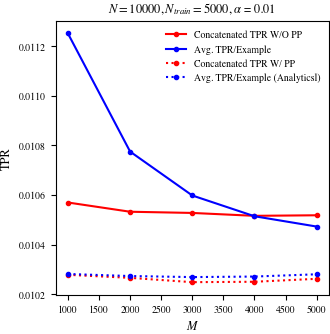

In [22]:
# from matplotlib.ticker import LogFormatterMathtext
with plt.rc_context(rc):
    fig, ax = plt.subplots(1,1)
    ax.plot(Rs, TPRs_pooled, color="r", marker=".",label="Concatenated TPR W/O PP")
    ax.plot(Rs, TPRs_px, color="b",marker=".",label=f"Avg. TPR/Example")
    ax.plot(Rs, TPRs_pooled_pp, color="r",linestyle=":", marker=".",label=f"Concatenated TPR W/ PP")
    ax.plot(Rs, TPRs_px_ana, color="b",linestyle=":", marker=".",label=f"Avg. TPR/Example (Analyticsl)")

    ax.set(xlabel=rf"$M$", ylabel="TPR")
    # ax.set_xscale("log", base=2)
    # ax.xaxis.set_major_formatter(LogFormatterMathtext(base=2))
    # ax.xaxis.set_minor_formatter(LogFormatterMathtext(base=2))
    ax.set_box_aspect(1)
    ax.legend()
    ax.set_title(rf"$N={N}, N_{{train}}={n_train}, \alpha$ = {alpha}")
    # plt.savefig(f"toy_px_vs_concat_N_{N}_N_train_{n_train}_fpr_{alpha}_v2.pdf")
    plt.show()

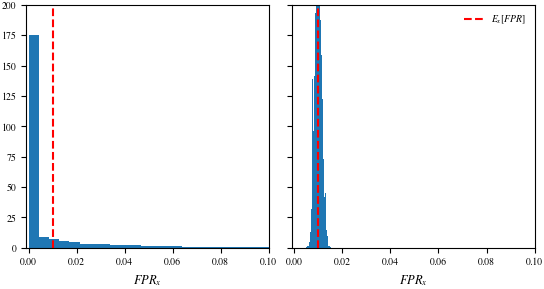

In [23]:
tau = np.quantile(all_llrs_out.reshape(-1), q=1 - alpha)
FPRs_px =  (all_llrs_out > tau).mean(axis=1)

tau_pp = np.quantile(all_llrs_out_pp.reshape(-1), q=1 - alpha)
FPRs_px_pp =  (all_llrs_out_pp > tau_pp).mean(axis=1)


with plt.rc_context(rc):
    fig, ax = plt.subplots(1,2,sharex="row",sharey="row")
    ax[0].hist(FPRs_px,bins=50,density=True)
    ax[0].axvline(x=0.01,color="r",linestyle="--",label=rf"$E_x[FPR]$")
    ax[0].set(xlabel=rf"$FPR_x$",ylim=[0,200], xlim=[-0.001,0.1])
    ax[0].set_box_aspect(1)

    ax[1].hist(FPRs_px_pp,bins=50,density=True)
    ax[1].axvline(x=0.01,color="r",linestyle="--",label=rf"$E_x[FPR]$")
    ax[1].set(xlabel=rf"$FPR_x$")
    ax[1].set_box_aspect(1)
    
    ax[1].legend()
    # plt.savefig("toy_px_fprs_at_concat_tau.pdf",bbox_inches="tight")
    plt.show()
